In [1]:
# imports y configuración global

import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score,
    precision_score, recall_score
)

from interpret.glassbox import ExplainableBoostingClassifier

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Librerías cargadas correctamente.')
print(f'Semilla global: {RANDOM_SEED}')


Librerías cargadas correctamente.
Semilla global: 42


In [2]:
# funciones de evaluacion y pipeline

# Etiquetas legibles para el reporte binario (DT Stage 1)
NOMBRES_BIN = {0: 'Normal', 1: 'Ataque'}

def _reporte(y_true, y_pred, class_names=None):
    """classification_report con nombres de clase si se proporcionan."""
    if class_names:
        labels = sorted(class_names.keys())
        target_names = [class_names[l] for l in labels]
        return classification_report(y_true, y_pred, labels=labels,
                                     target_names=target_names, zero_division=0)
    return classification_report(y_true, y_pred, zero_division=0)

def evaluar_modelo(model, X_test, y_test, nombre_dataset, nombre_modelo='EBM',
                   class_names=None):
    """Evaluacion estandar - misma que EBM.ipynb."""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)

    n_clases = len(np.unique(y_test))
    if n_clases == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    W = 60
    print('=' * W)
    print(f' {nombre_modelo} - {nombre_dataset}'.center(W))
    print('=' * W)
    print(f'  Accuracy   : {acc:.4f}')
    print(f'  Precision  : {prec:.4f}  (macro)')
    print(f'  Recall     : {rec:.4f}  (macro)')
    print(f'  F1-Score   : {f1:.4f}  (macro)')
    print(f'  AUC-ROC    : {auc:.4f}')
    print('-' * W)
    print(_reporte(y_test, y_pred, class_names))

    return {'dataset': nombre_dataset, 'accuracy': acc,
            'precision': prec, 'recall': rec,
            'f1_macro': f1, 'auc': auc}

def evaluar_pipeline(dt_model, ebm_model, X_test, y_test_bin, y_test_multi,
                     label_normal_multi, nombre_dataset, class_names=None):
    """
    Evalua el pipeline de 2 etapas:
      Stage 1: DT binario -> filtra normal (0) vs anomalia (1)
      Stage 2: EBM multiclase -> clasifica solo las instancias flagged

    Parametros:
      label_normal_multi: el valor de la clase 'Normal' en el encoding multiclase
                          (NSL-KDD=1, Mirai=0, DS2OS=0)
    """
    W = 60
    print('=' * W)
    print(f' PIPELINE 2 ETAPAS - {nombre_dataset}'.center(W))
    print('=' * W)

    # Stage 1: DT binario
    t0 = time.time()
    y_pred_bin = dt_model.predict(X_test)
    t_stage1 = time.time() - t0

    mask_flagged = (y_pred_bin == 1)  # anomalia segun DT
    n_flagged = mask_flagged.sum()
    n_total   = len(X_test)
    pct_filtered = (1 - n_flagged / n_total) * 100

    # Metricas Stage 1
    rec_s1 = recall_score(y_test_bin, y_pred_bin, pos_label=1)
    prec_s1 = precision_score(y_test_bin, y_pred_bin, pos_label=1, zero_division=0)
    f1_s1 = f1_score(y_test_bin, y_pred_bin, pos_label=1)

    print(f'\n--- Stage 1: Decision Tree Binario ---')
    print(f'  Instancias totales : {n_total:,}')
    print(f'  Flagged (anomalia) : {n_flagged:,} ({n_flagged/n_total*100:.1f}%)')
    print(f'  Filtradas (normal) : {n_total - n_flagged:,} ({pct_filtered:.1f}%)')
    print(f'  Recall  (ataques)  : {rec_s1:.5f}  <- CRITICO: ataques no perdidos')
    print(f'  Precision (ataques): {prec_s1:.4f}')
    print(f'  F1 (ataques)       : {f1_s1:.4f}')
    print(f'  Latencia Stage 1   : {t_stage1*1000:.2f} ms')

    # Ataques perdidos (Stage 1 recall < 1.0)
    ataques_reales = (y_test_bin == 1).sum()
    ataques_perdidos = ((y_test_bin == 1) & (y_pred_bin == 0)).sum()
    print(f'  Ataques reales     : {ataques_reales:,}')
    print(f'  Ataques PERDIDOS   : {ataques_perdidos:,}  '
          f'({ataques_perdidos/max(ataques_reales,1)*100:.2f}%)')

    # Stage 2: EBM multiclase solo sobre flagged
    y_final = np.full(n_total, label_normal_multi, dtype=y_test_multi.dtype)

    t_stage2 = 0.0
    if n_flagged > 0:
        t0 = time.time()
        y_ebm_pred = ebm_model.predict(X_test[mask_flagged])
        t_stage2 = time.time() - t0
        y_final[mask_flagged] = y_ebm_pred

    print(f'\n--- Stage 2: EBM Multiclase (solo flagged) ---')
    print(f'  Instancias procesadas: {n_flagged:,}')
    print(f'  Latencia Stage 2     : {t_stage2*1000:.2f} ms')
    print(f'  Latencia TOTAL       : {(t_stage1 + t_stage2)*1000:.2f} ms')

    # Metricas finales del pipeline (multiclase)
    acc  = accuracy_score(y_test_multi, y_final)
    f1   = f1_score(y_test_multi, y_final, average='macro', zero_division=0)
    prec = precision_score(y_test_multi, y_final, average='macro', zero_division=0)
    rec  = recall_score(y_test_multi, y_final, average='macro', zero_division=0)

    print(f'\n--- Metricas Finales del Pipeline (multiclase) ---')
    print(f'  Accuracy   : {acc:.4f}')
    print(f'  Precision  : {prec:.4f}  (macro)')
    print(f'  Recall     : {rec:.4f}  (macro)')
    print(f'  F1-Score   : {f1:.4f}  (macro)')
    print('-' * W)
    print(_reporte(y_test_multi, y_final, class_names))

    return {
        'dataset': nombre_dataset,
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_macro': f1,
        'stage1_recall': rec_s1, 'stage1_precision': prec_s1,
        'pct_filtered': pct_filtered,
        'ataques_perdidos': ataques_perdidos,
        'latencia_s1_ms': t_stage1 * 1000,
        'latencia_s2_ms': t_stage2 * 1000,
        'latencia_total_ms': (t_stage1 + t_stage2) * 1000,
    }


In [ ]:
    # funciones de explicabilidad para las tres etapas: explicar_dt() (stage 1) y explicar_ebm() (stage 2)
from sklearn.tree import plot_tree, export_text

def _slug(s):
    return s.lower().replace(' ', '_').replace('(', '').replace(')', '')

def explicar_dt(dt_model, feature_names, nombre_dataset, max_depth_plot=3):
    """Explicabilidad del Decision Tree (Stage 1, binario Normal vs Ataque).

    Tres vistas:
      1. Importancia de features (reduccion media de impureza Gini)
      2. Arbol podado a los primeros niveles (estructura legible)
      3. Reglas de decision en texto
    """
    feature_names = list(feature_names)
    W = 60
    print('=' * W)
    print(f' EXPLICABILIDAD DT Stage 1 - {nombre_dataset}'.center(W))
    print('=' * W)

    # Importancia de features (Gini)
    imp   = dt_model.feature_importances_
    orden = np.argsort(imp)[::-1]
    print('\nImportancia de features (reduccion de Gini):')
    for i in orden:
        if imp[i] > 0:
            print(f'  {feature_names[i]:<28} {imp[i]:.4f}')

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh([feature_names[i] for i in orden][::-1],
            [imp[i] for i in orden][::-1],
            color='seagreen', edgecolor='white')
    ax.set_xlabel('Importancia (reduccion de Gini)', fontsize=11)
    ax.set_title(f'Importancia de features - DT Stage 1 | {nombre_dataset}', fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    f1 = f'dt_{_slug(nombre_dataset)}_importancias.png'
    plt.savefig(f1, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {f1}')

    # Arbol podado (legible)
    fig, ax = plt.subplots(figsize=(16, 8))
    plot_tree(dt_model, max_depth=max_depth_plot, feature_names=feature_names,
              class_names=['Normal', 'Ataque'], filled=True, rounded=True,
              fontsize=8, impurity=False, proportion=True, ax=ax)
    ax.set_title(f'Arbol de decision (primeros {max_depth_plot} niveles) - {nombre_dataset}',
                 fontsize=13)
    plt.tight_layout()
    f2 = f'dt_{_slug(nombre_dataset)}_arbol.png'
    plt.savefig(f2, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {f2}')
    print(f'Profundidad total del arbol: {dt_model.get_depth()} | '
          f'Nº hojas: {dt_model.get_n_leaves()}')

    # Reglas en texto
    print(f'\nReglas de decision (primeros {max_depth_plot} niveles):')
    print(export_text(dt_model, feature_names=feature_names, max_depth=max_depth_plot))

def explicar_ebm(ebm_model, X_test, y_test_multi, feature_names,
                 class_names_dict, clase_interes, nombre_dataset):
    """Explicabilidad intrinseca del EBM (Stage 2, multiclase).

    clase_interes: etiqueta entera de la clase de ataque a analizar en la
                   funcion de forma y en la explicacion local.

    Tres vistas:
      1. Importancias globales de terminos (area de la funcion de forma)
      2. Funcion de forma del termino single mas importante (para clase_interes)
      3. Explicacion local de una muestra real de clase_interes
    """
    W = 60
    print('=' * W)
    print(f' EXPLICABILIDAD EBM Stage 2 - {nombre_dataset}'.center(W))
    print('=' * W)

    importancias = ebm_model.term_importances()
    nombres      = ebm_model.term_names_
    clases       = list(ebm_model.classes_)

    # columna de la clase de interes dentro de term_scores_ / eval_terms
    col_interes      = clases.index(clase_interes) if clase_interes in clases else 1
    nombre_clase_int = class_names_dict.get(clase_interes, str(clase_interes))

    # Importancias globales
    top_n      = min(15, len(importancias))
    idx_sorted = np.argsort(importancias)[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh([nombres[i] for i in idx_sorted][::-1],
            [importancias[i] for i in idx_sorted][::-1],
            color='steelblue', edgecolor='white')
    ax.set_xlabel('Importancia EBM (area de funcion de forma)', fontsize=11)
    ax.set_title(f'Top {top_n} terminos - EBM Stage 2 | {nombre_dataset}', fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    f1 = f'ebm_{_slug(nombre_dataset)}_importancias.png'
    plt.savefig(f1, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {f1}')

    # Funcion de forma del termino single mas importante
    single = [i for i in idx_sorted if len(ebm_model.term_features_[i]) == 1]
    feat_idx_top = single[0] if single else int(idx_sorted[0])
    feat_nombre  = nombres[feat_idx_top]
    ts_raw       = ebm_model.term_scores_[feat_idx_top]
    bin_edges    = ebm_model.bins_[feat_idx_top][0]
    term_scores  = ts_raw[:, col_interes] if ts_raw.ndim == 2 else ts_raw

    if len(bin_edges) > 1 and len(term_scores) > 1:
        x_vals = bin_edges[:-1]
        y_vals = term_scores[:len(x_vals)]
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.step(x_vals, y_vals, where='post', color='steelblue', linewidth=1.5)
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        ax.fill_between(x_vals, y_vals, 0, step='post',
                        where=[v > 0 for v in y_vals],
                        alpha=0.3, color='red', label=f'Empuja -> {nombre_clase_int}')
        ax.fill_between(x_vals, y_vals, 0, step='post',
                        where=[v < 0 for v in y_vals],
                        alpha=0.3, color='blue', label='Empuja -> otras clases')
        ax.set_xlabel(f'Valor de {feat_nombre}', fontsize=11)
        ax.set_ylabel('Contribucion al score (logit)', fontsize=11)
        ax.set_title(f'Funcion de forma EBM - {feat_nombre} | '
                     f'{nombre_dataset} ({nombre_clase_int})', fontsize=12)
        ax.legend(fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        f2 = f'ebm_{_slug(nombre_dataset)}_shape_{feat_nombre}.png'
        plt.savefig(f2, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Figura guardada: {f2}')

    # Explicacion local de una muestra de clase_interes
    idx_match = np.where(y_test_multi == clase_interes)[0]
    if len(idx_match) == 0:
        print(f'\n(No hay muestras de la clase {nombre_clase_int} en test; '
              f'se omite la explicacion local.)')
        return

    idx_local  = int(idx_match[0])
    muestra    = X_test[[idx_local]]
    pred_local = ebm_model.predict(muestra)[0]
    prob_local = ebm_model.predict_proba(muestra)[0]
    col_pred   = clases.index(pred_local)

    print(f'\nExplicacion local - muestra real "{nombre_clase_int}" (idx={idx_local})')
    print(f'  Prediccion EBM: {class_names_dict.get(pred_local, pred_local)}')
    for c, p in zip(clases, prob_local):
        print(f'  P({class_names_dict.get(c, c)}) = {p:.4f}')

    scores_loc = ebm_model.eval_terms(muestra)[0]
    scores_1d  = scores_loc[:, col_pred] if scores_loc.ndim == 2 else scores_loc

    contrib_df = (pd.DataFrame({'feature': nombres, 'contribucion': scores_1d})
                  .sort_values('contribucion', key=abs, ascending=False).head(10))
    print('\nTop 10 contribuciones locales (EBM):')
    print(contrib_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 4))
    colores = ['red' if v > 0 else 'steelblue' for v in contrib_df['contribucion']]
    ax.barh(contrib_df['feature'][::-1], contrib_df['contribucion'][::-1],
            color=colores[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Contribucion al score (logit)', fontsize=11)
    ax.set_title(f'Explicacion local - muestra '
                 f'{class_names_dict.get(pred_local, pred_local)} | {nombre_dataset}',
                 fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    f3 = f'ebm_{_slug(nombre_dataset)}_explicacion_local.png'
    plt.savefig(f3, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {f3}')

print('Funciones de explicabilidad listas: explicar_dt(), explicar_ebm()')


Funciones de explicabilidad listas: explicar_dt(), explicar_ebm()


---
## Dataset 1 — NSL-KDD

In [ ]:
# carga y preprocesamiento
# Preprocesamiento IDÉNTICO a EBM.ipynb / Clasificadores_NSL-KDD.ipynb

COL_NAMES = [
    'duration','protocol_type','service','flag',
    'src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell',
    'su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','label','difficulty'
]

SELECTED_FEATURES = [
    'src_bytes', 'service', 'dst_bytes', 'flag',
    'diff_srv_rate', 'same_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate',
]
FEATURE_COLS_NSL = SELECTED_FEATURES

CLASS_NAMES_NSL = {1: 'Normal', 2: 'DoS', 3: 'Probe', 4: 'R2L', 5: 'U2R'}

DOS   = {'back','land','neptune','pod','smurf','teardrop',
         'apache2','udpstorm','processtable','mailbomb'}
PROBE = {'ipsweep','nmap','portsweep','satan','mscan','saint'}
R2L   = {'ftp_write','guess_passwd','imap','multihop','phf','spy',
         'warezclient','warezmaster','sendmail','named',
         'snmpgetattack','snmpguess','xlock','xsnoop','worm'}
U2R   = {'buffer_overflow','loadmodule','perl','rootkit',
         'httptunnel','ps','sqlattack','xterm'}

def map_label_nsl(label):
    label = label.lower().strip()
    if label == 'normal': return 1
    if label in DOS:      return 2
    if label in PROBE:    return 3
    if label in R2L:      return 4
    if label in U2R:      return 5
    return 2

SEARCH_PATHS_NSL = [
    (Path.home() / ".cache" / "kagglehub" / "datasets" / "hassan06" / "nslkdd" / "versions" / "1" / "KDDTrain+_20Percent.txt"),
    Path("KDDTrain+_20Percent.txt"),
    Path.home() / "Downloads" / "KDDTrain+_20Percent.txt",
]

ruta_nsl = next((p for p in SEARCH_PATHS_NSL if p.exists()), None)
if ruta_nsl is None:
    raise FileNotFoundError("No se encontró KDDTrain+_20Percent.txt")

df_nsl = pd.read_csv(ruta_nsl, header=None, names=COL_NAMES).drop(columns=['difficulty'])

protocol_map = {'tcp': 1, 'udp': 2, 'icmp': 3}
df_nsl['protocol_type'] = df_nsl['protocol_type'].str.lower().map(protocol_map).fillna(0)
df_nsl['service'] = LabelEncoder().fit_transform(df_nsl['service'].astype(str))
df_nsl['flag']    = LabelEncoder().fit_transform(df_nsl['flag'].astype(str))

y_nsl_multi = df_nsl['label'].apply(map_label_nsl).values
y_nsl_bin   = (y_nsl_multi > 1).astype(int)  # 0=Normal, 1=Ataque

X_nsl = df_nsl[SELECTED_FEATURES].values.astype(np.float32)

# Split 80/20 estratificado — se preservan ambas etiquetas
X_tr_nsl, X_te_nsl, y_tr_multi_nsl, y_te_multi_nsl, y_tr_bin_nsl, y_te_bin_nsl = train_test_split(
    X_nsl, y_nsl_multi, y_nsl_bin,
    test_size=0.20, random_state=RANDOM_SEED, stratify=y_nsl_multi
)

scaler_nsl = MinMaxScaler()
X_tr_nsl = scaler_nsl.fit_transform(X_tr_nsl)
X_te_nsl = scaler_nsl.transform(X_te_nsl)

print(f'NSL-KDD cargado: {len(df_nsl):,} instancias')
print(f'Features: {len(SELECTED_FEATURES)} | Train: {len(X_tr_nsl):,} | Test: {len(X_te_nsl):,}')
print(f'Tasa de anomalías: {y_nsl_bin.mean()*100:.1f}%')


NSL-KDD cargado: 25,192 instancias
Features: 8 | Train: 20,153 | Test: 5,039
Tasa de anomalías: 46.6%


In [ ]:
    # stage 1, arbol de decision binario. class_weight='balanced' para no perder ataques, sin limite de profundidad

dt_nsl = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=RANDOM_SEED,
)

print('Entrenando DT binario en NSL-KDD...')
t0 = time.time()
dt_nsl.fit(X_tr_nsl, y_tr_bin_nsl)
t_train_dt = time.time() - t0
print(f'Entrenamiento DT completado en {t_train_dt:.2f}s')

# Evaluación standalone del DT
evaluar_modelo(dt_nsl, X_te_nsl, y_te_bin_nsl,
               nombre_dataset='NSL-KDD (Binario)', nombre_modelo='DT Stage 1', class_names=NOMBRES_BIN)


Entrenando DT binario en NSL-KDD...
Entrenamiento DT completado en 0.04s
               DT Stage 1 - NSL-KDD (Binario)               
  Accuracy   : 0.9942
  Precision  : 0.9942  (macro)
  Recall     : 0.9943  (macro)
  F1-Score   : 0.9942  (macro)
  AUC-ROC    : 0.9943
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      2690
      Ataque       0.99      0.99      0.99      2349

    accuracy                           0.99      5039
   macro avg       0.99      0.99      0.99      5039
weighted avg       0.99      0.99      0.99      5039



{'dataset': 'NSL-KDD (Binario)',
 'accuracy': 0.994244889859099,
 'precision': 0.9941544880222895,
 'recall': 0.9942858702825375,
 'f1_macro': 0.9942191871591117,
 'auc': 0.9942858702825375}

In [ ]:
# stage 2, EBM multiclase
# Misma configuración que EBM.ipynb

ebm_nsl = ExplainableBoostingClassifier(
    max_bins         = 256,
    interactions     = 10,
    learning_rate    = 0.01,
    max_rounds       = 5000,
    min_samples_leaf = 2,
    random_state     = RANDOM_SEED,
    feature_names    = FEATURE_COLS_NSL,
)

print('Entrenando EBM multiclase en NSL-KDD...')
t0 = time.time()
ebm_nsl.fit(X_tr_nsl, y_tr_multi_nsl)
t_train_ebm = time.time() - t0
print(f'Entrenamiento EBM completado en {t_train_ebm:.2f}s')

# Evaluación standalone del EBM (baseline a batir)
res_ebm_nsl = evaluar_modelo(ebm_nsl, X_te_nsl, y_te_multi_nsl,
                              nombre_dataset='NSL-KDD (Multiclase)', nombre_modelo='EBM directo', class_names=CLASS_NAMES_NSL)


Entrenando EBM multiclase en NSL-KDD...
Entrenamiento EBM completado en 288.84s
             EBM directo - NSL-KDD (Multiclase)             
  Accuracy   : 0.9946
  Precision  : 0.8903  (macro)
  Recall     : 0.8632  (macro)
  F1-Score   : 0.8757  (macro)
  AUC-ROC    : 0.9663
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      2690
         DoS       1.00      1.00      1.00      1847
       Probe       0.99      0.99      0.99       458
         R2L       0.97      0.83      0.90        42
         U2R       0.50      0.50      0.50         2

    accuracy                           0.99      5039
   macro avg       0.89      0.86      0.88      5039
weighted avg       0.99      0.99      0.99      5039



In [ ]:
# evaluación del pipeline completo
# NSL-KDD: Normal = 1 en encoding multiclase

res_pipe_nsl = evaluar_pipeline(
    dt_model=dt_nsl,
    ebm_model=ebm_nsl,
    X_test=X_te_nsl,
    y_test_bin=y_te_bin_nsl,
    y_test_multi=y_te_multi_nsl,
    label_normal_multi=1,   # NSL-KDD: Normal=1
    nombre_dataset='NSL-KDD',
    class_names=CLASS_NAMES_NSL
)


                 PIPELINE 2 ETAPAS - NSL-KDD                

--- Stage 1: Decision Tree Binario ---
  Instancias totales : 5,039
  Flagged (anomalia) : 2,354 (46.7%)
  Filtradas (normal) : 2,685 (53.3%)
  Recall  (ataques)  : 0.99489  <- CRITICO: ataques no perdidos
  Precision (ataques): 0.9928
  F1 (ataques)       : 0.9938
  Latencia Stage 1   : 3.55 ms
  Ataques reales     : 2,349
  Ataques PERDIDOS   : 12  (0.51%)

--- Stage 2: EBM Multiclase (solo flagged) ---
  Instancias procesadas: 2,354
  Latencia Stage 2     : 6.23 ms
  Latencia TOTAL       : 9.78 ms

--- Metricas Finales del Pipeline (multiclase) ---
  Accuracy   : 0.9935
  Precision  : 0.8894  (macro)
  Recall     : 0.8475  (macro)
  F1-Score   : 0.8660  (macro)
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      2690
         DoS       1.00      1.00      1.00      1847
       Probe       0.99      0.98      0.

### Explicabilidad — NSL-KDD

             EXPLICABILIDAD DT Stage 1 - NSL-KDD            

Importancia de features (reduccion de Gini):
  src_bytes                    0.7969
  dst_bytes                    0.0623
  dst_host_srv_count           0.0538
  service                      0.0422
  dst_host_same_srv_rate       0.0219
  flag                         0.0145
  diff_srv_rate                0.0079
  same_srv_rate                0.0005


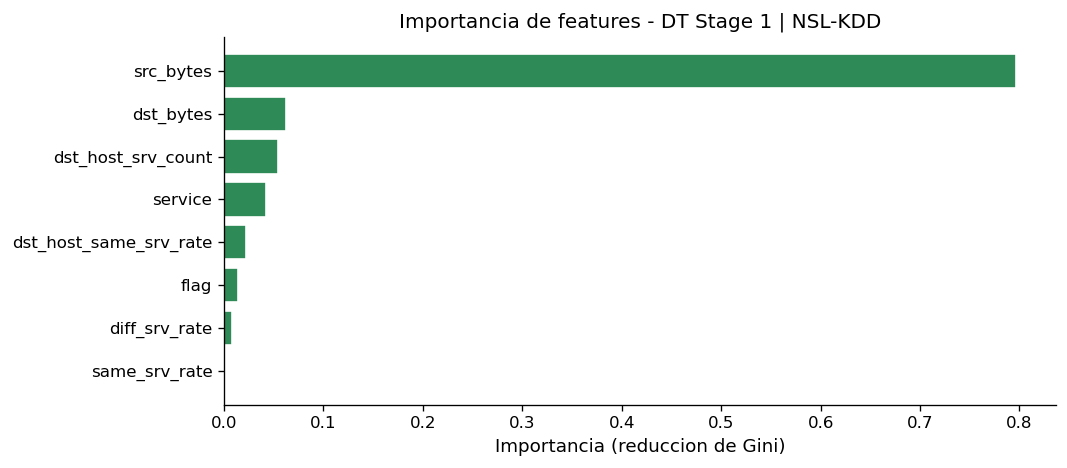

Figura guardada: dt_nsl-kdd_importancias.png


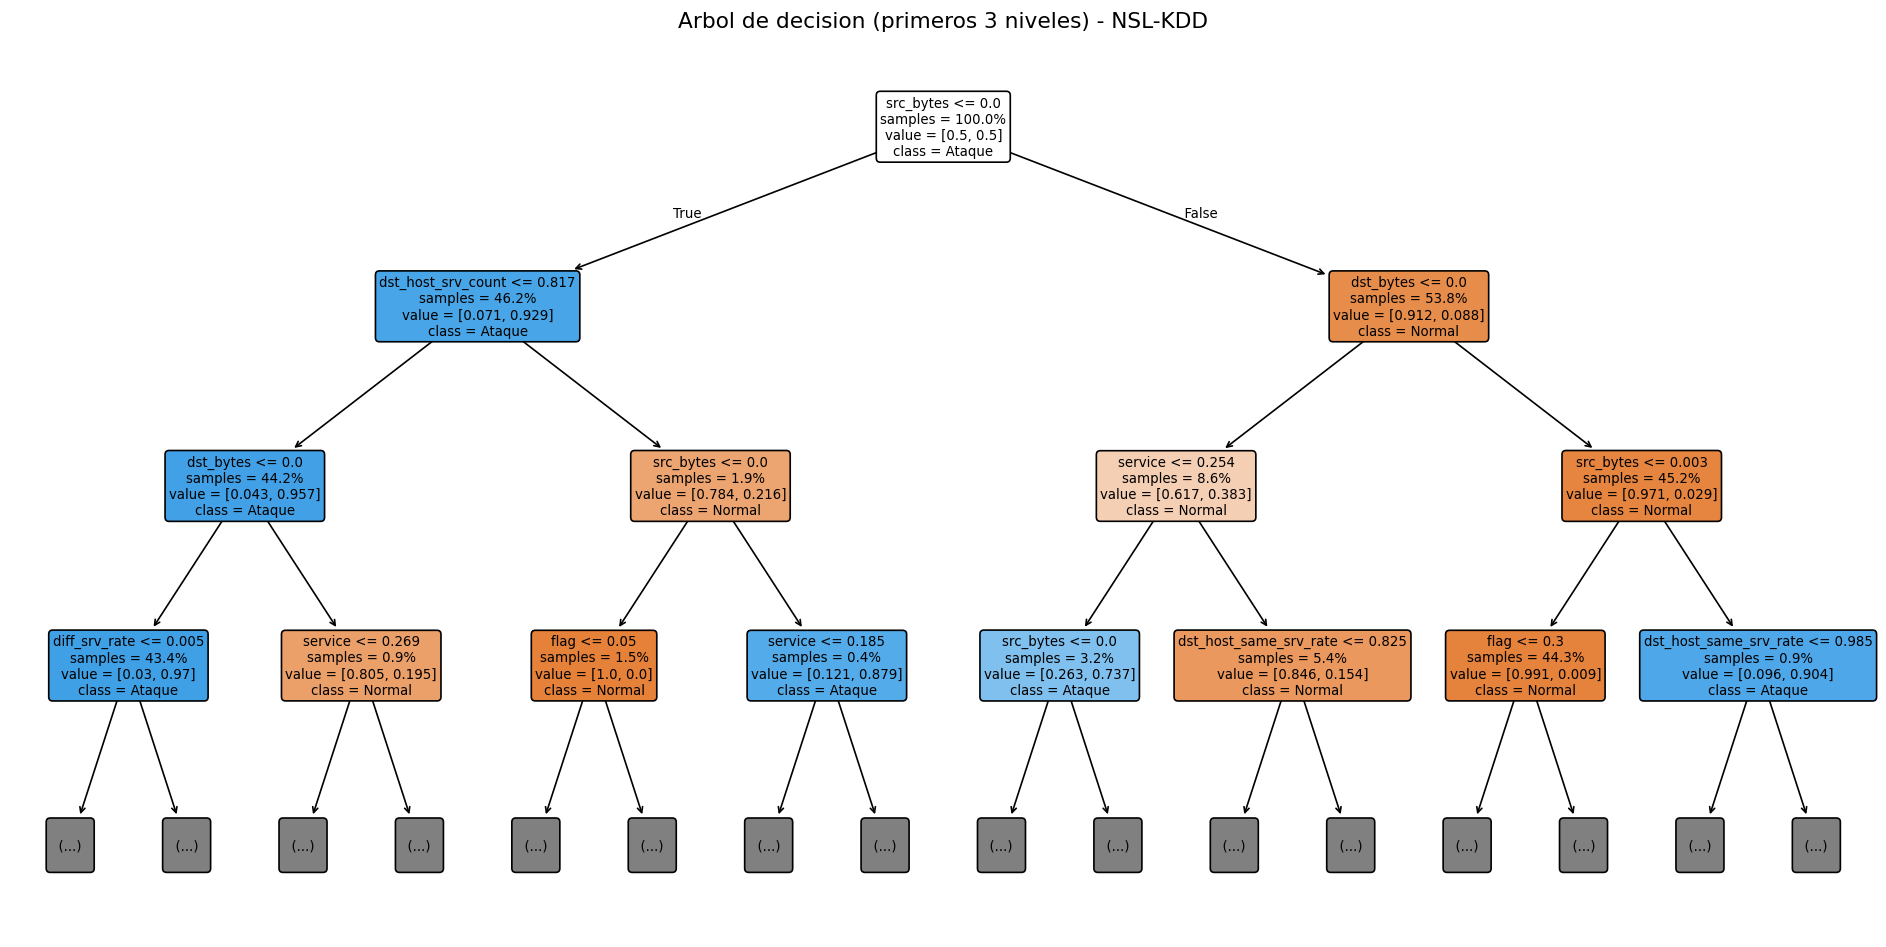

Figura guardada: dt_nsl-kdd_arbol.png
Profundidad total del arbol: 14 | Nº hojas: 163

Reglas de decision (primeros 3 niveles):
|--- src_bytes <= 0.00
|   |--- dst_host_srv_count <= 0.82
|   |   |--- dst_bytes <= 0.00
|   |   |   |--- diff_srv_rate <= 0.00
|   |   |   |   |--- truncated branch of depth 11
|   |   |   |--- diff_srv_rate >  0.00
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- dst_bytes >  0.00
|   |   |   |--- service <= 0.27
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- service >  0.27
|   |   |   |   |--- truncated branch of depth 6
|   |--- dst_host_srv_count >  0.82
|   |   |--- src_bytes <= 0.00
|   |   |   |--- flag <= 0.05
|   |   |   |   |--- class: 0
|   |   |   |--- flag >  0.05
|   |   |   |   |--- class: 0
|   |   |--- src_bytes >  0.00
|   |   |   |--- service <= 0.18
|   |   |   |   |--- class: 0
|   |   |   |--- service >  0.18
|   |   |   |   |--- class: 1
|--- src_bytes >  0.00
|   |--- dst_bytes <= 0.00
|   |   |--- ser

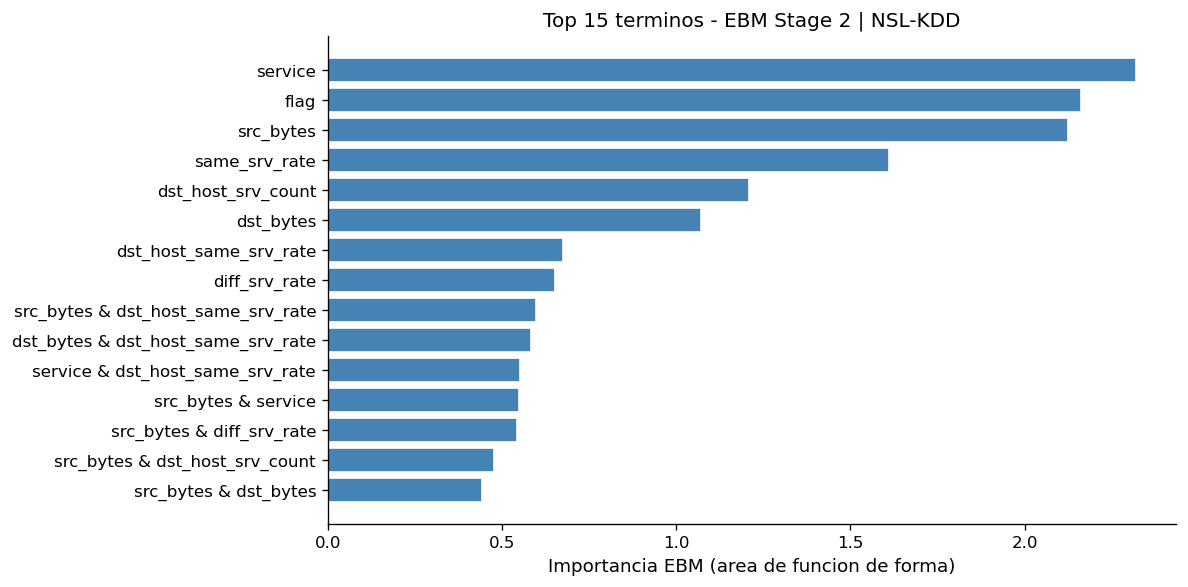

Figura guardada: ebm_nsl-kdd_importancias.png


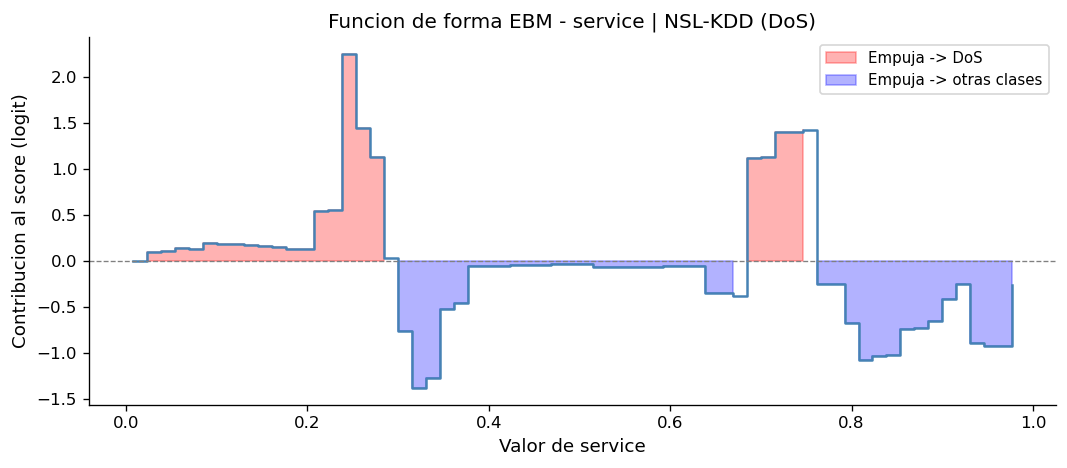

Figura guardada: ebm_nsl-kdd_shape_service.png

Explicacion local - muestra real "DoS" (idx=1)
  Prediccion EBM: DoS
  P(Normal) = 0.0000
  P(DoS) = 1.0000
  P(Probe) = 0.0000
  P(R2L) = 0.0000
  P(U2R) = 0.0000

Top 10 contribuciones locales (EBM):
                         feature  contribucion
                            flag      2.144050
                   diff_srv_rate      1.971541
                       dst_bytes      1.031555
                   same_srv_rate      0.784181
       src_bytes & diff_srv_rate      0.743462
           src_bytes & dst_bytes      0.700574
                       src_bytes      0.380594
          dst_host_same_srv_rate      0.375474
service & dst_host_same_srv_rate      0.346086
             src_bytes & service      0.213305


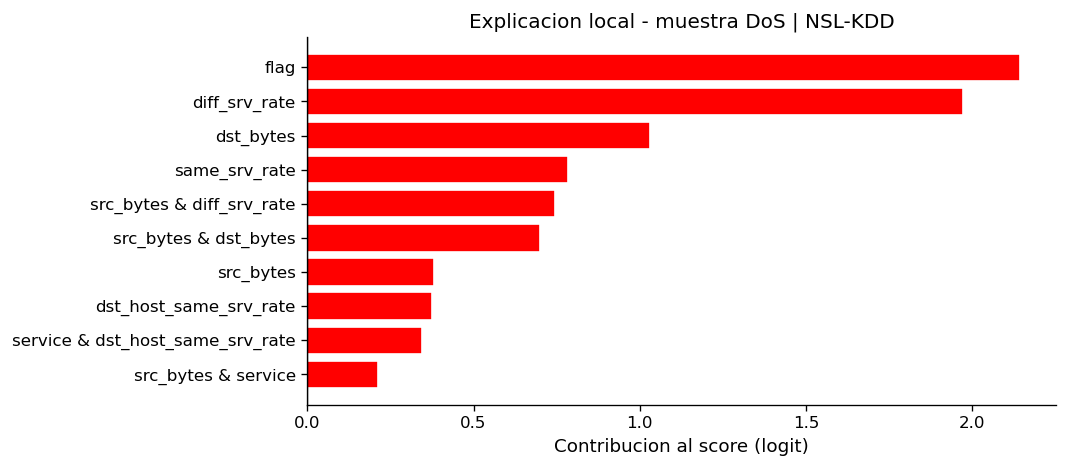

Figura guardada: ebm_nsl-kdd_explicacion_local.png


In [ ]:
# explicabilidad DT + EBM
explicar_dt(dt_nsl, FEATURE_COLS_NSL, 'NSL-KDD')

explicar_ebm(
    ebm_model=ebm_nsl,
    X_test=X_te_nsl,
    y_test_multi=y_te_multi_nsl,
    feature_names=FEATURE_COLS_NSL,
    class_names_dict=CLASS_NAMES_NSL,
    clase_interes=2,   # DoS
    nombre_dataset='NSL-KDD',
)


---
## Dataset 2 — Mirai

In [ ]:
# carga y preprocesamiento
# Preprocesamiento IDÉNTICO a EBM.ipynb / Clasificadores_Mirai.ipynb

def reclassify_state_mirai(row):
    proto  = row.get('state', row.get('proto', 'OTHER'))
    b_pkts = row.get('b_pkts', 0)
    avg_ps = row.get('avg_pkt_size', 0)
    if proto == 'DNS':             return 'DNS_FLOOD'
    if proto in ('HTTP','HTTPS'):  return 'HTTP_FLOOD'
    if proto == 'SSH':             return 'OTHER'
    if proto == 'UDP_OTHER':
        if b_pkts == 0 and avg_ps < 100: return 'UDP_SMALL_NORESPONSE'
        elif b_pkts == 0:                return 'UDP_LARGE_NORESPONSE'
        else:                            return 'UDP_BIDIRECTIONAL'
    if proto == 'TCP_OTHER':
        if b_pkts == 0 and avg_ps < 80: return 'TCP_SYN_LIKE'
        elif b_pkts == 0:               return 'TCP_ACK_LIKE'
        else:                           return 'TCP_ESTABLISHED'
    return 'OTHER'

HWANG_CLASS_TOTAL = {
    'Normal':      76725, 'ACK_Flood':    7425,
    'DNS_Flood':    4851, 'Mirai_CnC':   76725,
    'GREIP_Flood': 27801, 'HTTP_Flood':    135,
    'SYN_Flood':   76725, 'UDP_Flood':   31878,
    'VSE_Flood':    4986,
}

FEATURE_COLS_MIRAI = [
    'n_pkts','n_bytes','f_pkts','f_bytes',
    'b_pkts','b_bytes','avg_pkt_size','duration','state'
]

CLASS_NAMES_MIRAI = list(HWANG_CLASS_TOTAL.keys())
CLASS_NAMES_MIRAI_DICT = {i: n for i, n in enumerate(CLASS_NAMES_MIRAI)}

def find_mirai_file():
    canonical = (Path.cwd().parent / "data" / "flows.csv")
    if canonical.exists():
        return canonical
    for base in [Path('.'), Path.home()/'Downloads', Path.home()/'.cache',
                 Path.home()/'markov_mirai']:
        for f in base.rglob('*.csv'):
            if any(k in f.name.lower() for k in ('mirai', 'hwang', 'flows')):
                return f
    raise FileNotFoundError(
        "No se encontró el dataset Mirai.\n"
        "Ruta esperada: C:\\Users\\user\\markov_mirai\\flows.csv"
    )

try:
    ruta_mirai = find_mirai_file()
    print(f'Cargando Mirai desde: {ruta_mirai}')
    df_mirai = pd.read_csv(ruta_mirai)

    if 'state' in df_mirai.columns:
        df_mirai['state'] = df_mirai.apply(reclassify_state_mirai, axis=1)

    np.random.seed(RANDOM_SEED)
    idx_keep = []
    for cls_name, n_total in HWANG_CLASS_TOTAL.items():
        if 'class_name' not in df_mirai.columns: continue
        idx_cls = np.where(df_mirai['class_name'].values == cls_name)[0]
        if len(idx_cls) == 0: continue
        if len(idx_cls) > n_total:
            idx_cls = np.random.choice(idx_cls, n_total, replace=False)
        idx_keep.append(idx_cls)
    if idx_keep:
        df_mirai = df_mirai.iloc[np.sort(np.concatenate(idx_keep))].reset_index(drop=True)

    le_state = LabelEncoder()
    df_mirai['state'] = le_state.fit_transform(df_mirai['state'].astype(str))

    class_to_int_mirai = {c: i for i, c in enumerate(CLASS_NAMES_MIRAI)}
    y_mirai_multi = df_mirai['class_name'].map(class_to_int_mirai).values
    y_mirai_bin   = df_mirai['label'].values.astype(int)

    feats_mirai = [f for f in FEATURE_COLS_MIRAI if f in df_mirai.columns]
    X_mirai = df_mirai[feats_mirai].apply(pd.to_numeric, errors='coerce').fillna(0).values.astype(np.float32)

    # Split 80/20 — preservamos AMBAS etiquetas (binaria Y multiclase)
    Xm_tr, Xm_te, ym_tr_multi, ym_te_multi, ym_tr_bin, ym_te_bin = train_test_split(
        X_mirai, y_mirai_multi, y_mirai_bin,
        test_size=0.20, random_state=RANDOM_SEED, stratify=y_mirai_multi
    )

    scaler_mirai = MinMaxScaler()
    Xm_tr = scaler_mirai.fit_transform(Xm_tr)
    Xm_te = scaler_mirai.transform(Xm_te)

    print(f'Mirai cargado: {len(df_mirai):,} instancias')
    print(f'Features: {len(feats_mirai)} | Train: {len(Xm_tr):,} | Test: {len(Xm_te):,}')
    print(f'Tasa de anomalías: {y_mirai_bin.mean()*100:.1f}%')
    MIRAI_DISPONIBLE = True

except FileNotFoundError as e:
    print(f'AVISO: {e}')
    MIRAI_DISPONIBLE = False


Cargando Mirai desde: C:\Users\user\markov_mirai\flows.csv
Mirai cargado: 161,384 instancias
Features: 9 | Train: 129,107 | Test: 32,277
Tasa de anomalías: 95.2%


In [ ]:
# stage 1: Decision Tree binario

if MIRAI_DISPONIBLE:
    dt_mirai = DecisionTreeClassifier(
        class_weight='balanced',
        random_state=RANDOM_SEED,
    )

    print('Entrenando DT binario en Mirai...')
    t0 = time.time()
    dt_mirai.fit(Xm_tr, ym_tr_bin)
    t_train_dt = time.time() - t0
    print(f'Entrenamiento DT completado en {t_train_dt:.2f}s')

    evaluar_modelo(dt_mirai, Xm_te, ym_te_bin,
                   nombre_dataset='Mirai (Binario)', nombre_modelo='DT Stage 1', class_names=NOMBRES_BIN)
else:
    print('Mirai no disponible — bloque saltado.')


Entrenando DT binario en Mirai...
Entrenamiento DT completado en 0.48s
                DT Stage 1 - Mirai (Binario)                
  Accuracy   : 0.9982
  Precision  : 0.9862  (macro)
  Recall     : 0.9948  (macro)
  F1-Score   : 0.9905  (macro)
  AUC-ROC    : 0.9956
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98      1559
      Ataque       1.00      1.00      1.00     30718

    accuracy                           1.00     32277
   macro avg       0.99      0.99      0.99     32277
weighted avg       1.00      1.00      1.00     32277



In [ ]:
# stage 2: EBM multiclase (9 clases)

if MIRAI_DISPONIBLE:
    ebm_mirai = ExplainableBoostingClassifier(
        max_bins         = 256,
        interactions     = 10,
        learning_rate    = 0.01,
        max_rounds       = 5000,
        min_samples_leaf = 2,
        random_state     = RANDOM_SEED,
        feature_names    = feats_mirai,
    )

    print('Entrenando EBM multiclase en Mirai (9 clases)...')
    t0 = time.time()
    ebm_mirai.fit(Xm_tr, ym_tr_multi)
    t_train_ebm = time.time() - t0
    print(f'Entrenamiento EBM completado en {t_train_ebm:.2f}s')

    res_ebm_mirai = evaluar_modelo(ebm_mirai, Xm_te, ym_te_multi,
                                    nombre_dataset='Mirai (Multiclase 9 clases)',
                                    nombre_modelo='EBM directo', class_names=CLASS_NAMES_MIRAI_DICT)
else:
    print('Mirai no disponible — bloque saltado.')


Entrenando EBM multiclase en Mirai (9 clases)...
Entrenamiento EBM completado en 1052.82s
          EBM directo - Mirai (Multiclase 9 clases)         
  Accuracy   : 0.9657
  Precision  : 0.8484  (macro)
  Recall     : 0.7619  (macro)
  F1-Score   : 0.7639  (macro)
  AUC-ROC    : 0.9841
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98      1559
   ACK_Flood       1.00      0.88      0.94      1485
   DNS_Flood       1.00      0.99      0.99       970
   Mirai_CnC       0.85      0.98      0.91      5014
 GREIP_Flood       0.50      0.00      0.01       504
  HTTP_Flood       0.33      0.04      0.07        27
   SYN_Flood       0.99      0.99      0.99     15345
   UDP_Flood       1.00      0.98      0.99      6376
   VSE_Flood       1.00      0.99      1.00       997

    accuracy                           0.97     32277
   macro avg       0.85      0.76      0.76     32277
w

In [ ]:
# evaluación del Pipeline completo
# Mirai: Normal = 0 en encoding multiclase

if MIRAI_DISPONIBLE:
    res_pipe_mirai = evaluar_pipeline(
        dt_model=dt_mirai,
        ebm_model=ebm_mirai,
        X_test=Xm_te,
        y_test_bin=ym_te_bin,
        y_test_multi=ym_te_multi,
        label_normal_multi=0,   # Mirai: Normal=0
        nombre_dataset='Mirai',
        class_names=CLASS_NAMES_MIRAI_DICT
    )
else:
    print('Mirai no disponible — bloque saltado.')


                  PIPELINE 2 ETAPAS - Mirai                 

--- Stage 1: Decision Tree Binario ---
  Instancias totales : 32,277
  Flagged (anomalia) : 30,689 (95.1%)
  Filtradas (normal) : 1,588 (4.9%)
  Recall  (ataques)  : 0.9986  <- CRITICO: ataques no perdidos
  Precision (ataques): 0.9995
  F1 (ataques)       : 0.9991
  Latencia Stage 1   : 6.89 ms
  Ataques reales     : 30,718
  Ataques PERDIDOS   : 43  (0.14%)

--- Stage 2: EBM Multiclase (solo flagged) ---
  Instancias procesadas: 30,689
  Latencia Stage 2     : 30.24 ms
  Latencia TOTAL       : 37.13 ms

--- Metricas Finales del Pipeline (multiclase) ---
  Accuracy   : 0.9657
  Precision  : 0.8478  (macro)
  Recall     : 0.7622  (macro)
  F1-Score   : 0.7637  (macro)
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98      1559
   ACK_Flood       1.00      0.88      0.94      1485
   DNS_Flood       1.00      0.99    

### Explicabilidad — Mirai

              EXPLICABILIDAD DT Stage 1 - Mirai             

Importancia de features (reduccion de Gini):
  avg_pkt_size                 0.5898
  f_bytes                      0.4011
  state                        0.0046
  duration                     0.0023
  n_bytes                      0.0007
  b_bytes                      0.0005
  b_pkts                       0.0005
  n_pkts                       0.0003
  f_pkts                       0.0002


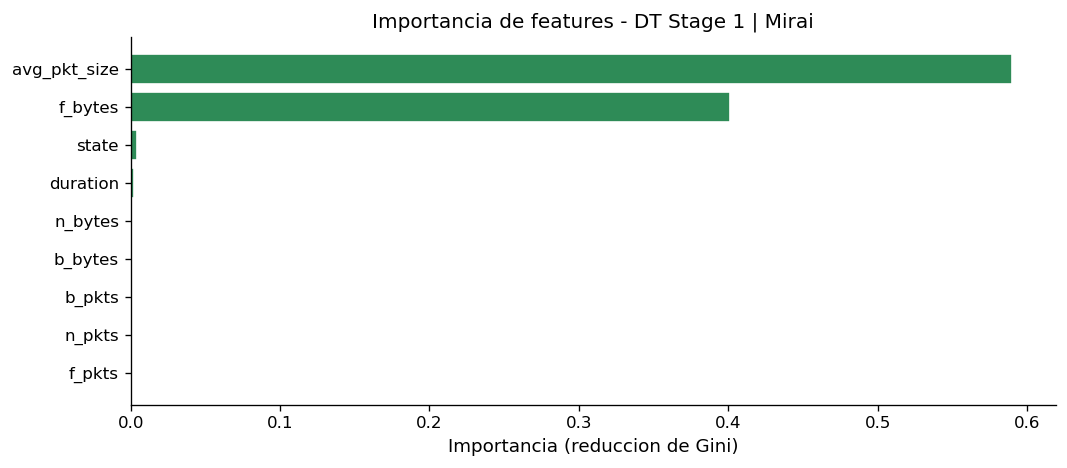

Figura guardada: dt_mirai_importancias.png


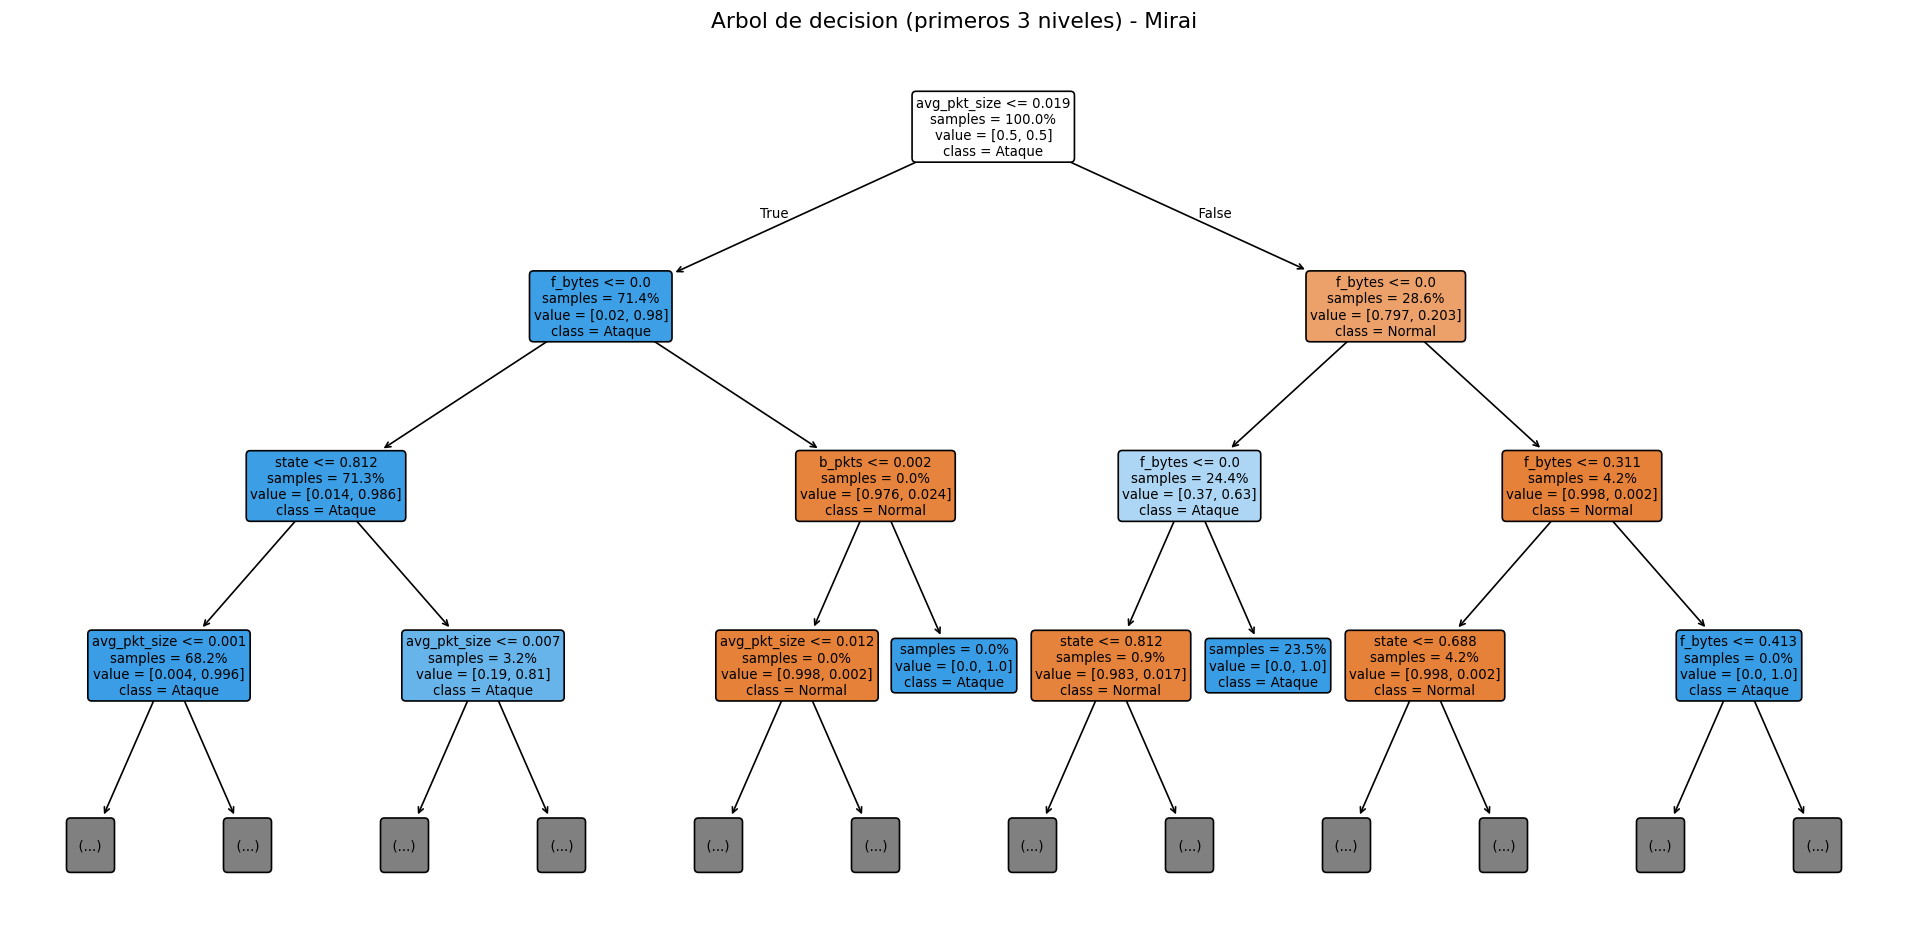

Figura guardada: dt_mirai_arbol.png
Profundidad total del arbol: 28 | Nº hojas: 255

Reglas de decision (primeros 3 niveles):
|--- avg_pkt_size <= 0.02
|   |--- f_bytes <= 0.00
|   |   |--- state <= 0.81
|   |   |   |--- avg_pkt_size <= 0.00
|   |   |   |   |--- class: 0
|   |   |   |--- avg_pkt_size >  0.00
|   |   |   |   |--- truncated branch of depth 7
|   |   |--- state >  0.81
|   |   |   |--- avg_pkt_size <= 0.01
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- avg_pkt_size >  0.01
|   |   |   |   |--- truncated branch of depth 7
|   |--- f_bytes >  0.00
|   |   |--- b_pkts <= 0.00
|   |   |   |--- avg_pkt_size <= 0.01
|   |   |   |   |--- class: 0
|   |   |   |--- avg_pkt_size >  0.01
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- b_pkts >  0.00
|   |   |   |--- class: 1
|--- avg_pkt_size >  0.02
|   |--- f_bytes <= 0.00
|   |   |--- f_bytes <= 0.00
|   |   |   |--- state <= 0.81
|   |   |   |   |--- truncated branch of depth 18
|   |   |   |--- 

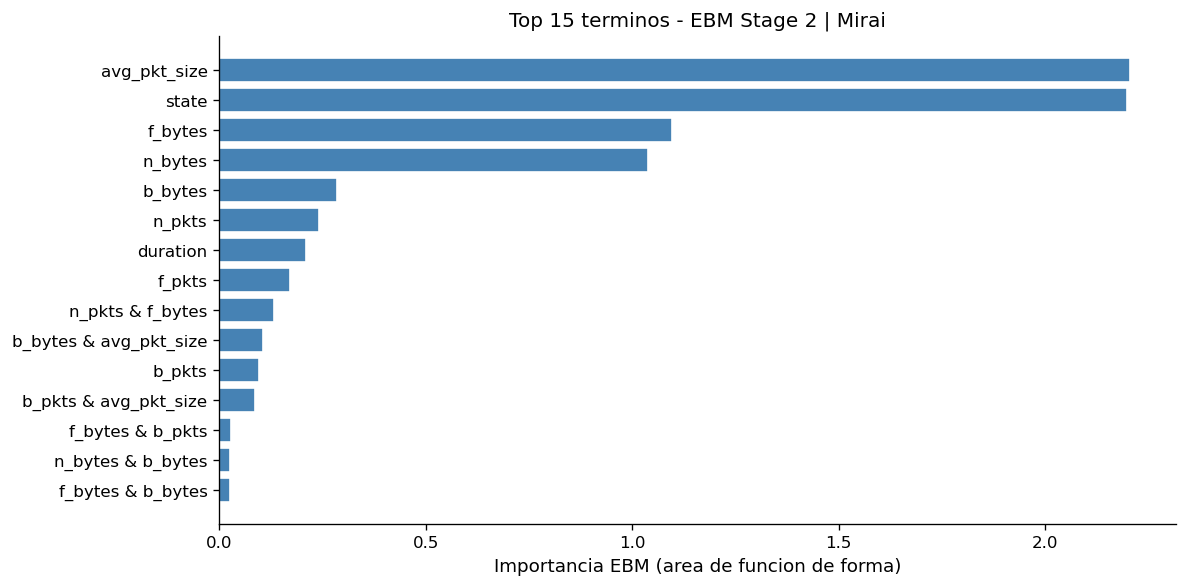

Figura guardada: ebm_mirai_importancias.png


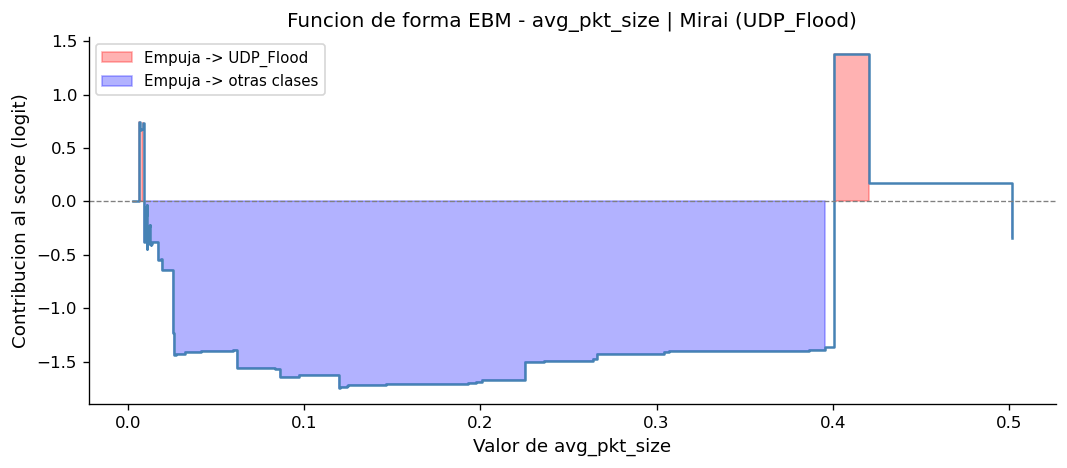

Figura guardada: ebm_mirai_shape_avg_pkt_size.png

Explicacion local - muestra real "UDP_Flood" (idx=5)
  Prediccion EBM: UDP_Flood
  P(Normal) = 0.0003
  P(ACK_Flood) = 0.0000
  P(DNS_Flood) = 0.0000
  P(Mirai_CnC) = 0.0001
  P(GREIP_Flood) = 0.0000
  P(HTTP_Flood) = 0.0000
  P(SYN_Flood) = 0.0000
  P(UDP_Flood) = 0.9996
  P(VSE_Flood) = 0.0000

Top 10 contribuciones locales (EBM):
         feature  contribucion
         n_bytes      2.581080
         f_bytes      2.347400
    avg_pkt_size      1.382481
           state      1.152806
n_pkts & f_bytes      0.183139
         b_bytes     -0.114122
          b_pkts     -0.101333
          n_pkts      0.089047
f_bytes & b_pkts      0.057074
          f_pkts     -0.046993


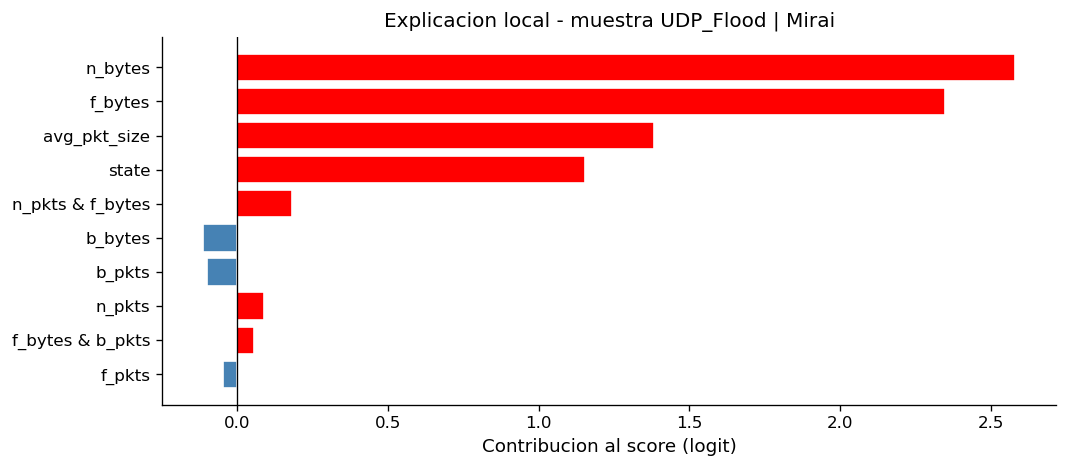

Figura guardada: ebm_mirai_explicacion_local.png


In [ ]:
# explicabilidad DT + EBM
if MIRAI_DISPONIBLE:
    explicar_dt(dt_mirai, feats_mirai, 'Mirai')

    explicar_ebm(
        ebm_model=ebm_mirai,
        X_test=Xm_te,
        y_test_multi=ym_te_multi,
        feature_names=feats_mirai,
        class_names_dict=CLASS_NAMES_MIRAI_DICT,
        clase_interes=7,   # UDP_Flood
        nombre_dataset='Mirai',
    )
else:
    print('Mirai no disponible — bloque saltado.')


---
## Dataset 3 — DS2OS

In [ ]:
# carga y preprocesamiento
# Preprocesamiento IDÉNTICO a EBM.ipynb / CLASIFICADORES_DS2OS.ipynb

CLASS_MAP = {
    'normal'                        : 'Normal',
    'anomalous(DoSattack)'          : 'DoS',
    'anomalous(scan)'               : 'Scan',
    'anomalous(malitiousControl)'   : 'MaliciousControl',
    'anomalous(malitiousOperation)' : 'MaliciousOperation',
    'anomalous(spying)'             : 'Spying',
    'anomalous(dataProbing)'        : 'DataProbing',
    'anomalous(wrongSetUp)'         : 'WrongSetUp',
}
CLASS_TO_INT = {v: i for i, v in enumerate(CLASS_MAP.values())}
INT_TO_CLASS = {v: k for k, v in CLASS_TO_INT.items()}

CAT_COLS_DS2OS = [
    'sourceID', 'sourceAddress', 'sourceType', 'sourceLocation',
    'destinationServiceAddress', 'destinationServiceType',
    'destinationLocation', 'accessedNodeAddress', 'accessedNodeType', 'operation',
]
FEAT_DS2OS = CAT_COLS_DS2OS + ['value']

SEARCH_PATHS_DS2OS = [
    Path("DS2OS.csv"),
    Path.home() / "Downloads" / "DS2OS.csv",
    (Path.home() / ".cache" / "kagglehub" / "datasets" / "libamariyam" / "ds2os-dataset" / "versions" / "1" / "DS2OS.csv"),
]

try:
    ruta_ds2os = next((p for p in SEARCH_PATHS_DS2OS if p.exists()), None)
    if ruta_ds2os is None:
        raise FileNotFoundError("No se encontró DS2OS.csv")

    print(f'Cargando DS2OS desde: {ruta_ds2os}')
    df_ds2os = pd.read_csv(ruta_ds2os)

    df_ds2os['accessedNodeType'] = df_ds2os['accessedNodeType'].fillna('Malicious')
    df_ds2os['value'] = df_ds2os['value'].replace({'False': 0, 'True': 1, 'Twenty': 20, 'none': 0})
    df_ds2os['value'] = pd.to_numeric(df_ds2os['value'], errors='coerce').fillna(0)
    df_ds2os = df_ds2os.drop(columns=['timestamp'])

    df_ds2os['y'] = df_ds2os['normality'].map(CLASS_MAP).map(CLASS_TO_INT).astype(np.int8)
    y_ds2os_bin   = (df_ds2os['normality'] != 'normal').astype(int).values
    df_ds2os = df_ds2os.drop(columns=['normality'])

    for col in CAT_COLS_DS2OS:
        df_ds2os[col] = LabelEncoder().fit_transform(df_ds2os[col].astype(str))

    X_ds2os       = df_ds2os[FEAT_DS2OS].values.astype(np.float32)
    y_ds2os_multi = df_ds2os['y'].values

    # Split 80/20 — preservamos AMBAS etiquetas
    Xd_tr, Xd_te, yd_tr_multi, yd_te_multi, yd_tr_bin, yd_te_bin = train_test_split(
        X_ds2os, y_ds2os_multi, y_ds2os_bin,
        test_size=0.20, random_state=RANDOM_SEED, stratify=y_ds2os_multi
    )
    scaler_ds2os = StandardScaler()
    Xd_tr = scaler_ds2os.fit_transform(Xd_tr)
    Xd_te = scaler_ds2os.transform(Xd_te)

    print(f'DS2OS cargado: {len(df_ds2os):,} instancias')
    print(f'Features: {len(FEAT_DS2OS)} | Train: {len(Xd_tr):,} | Test: {len(Xd_te):,}')
    print(f'Tasa de anomalías: {y_ds2os_bin.mean()*100:.1f}%')
    DS2OS_DISPONIBLE = True

except FileNotFoundError as e:
    print(f'AVISO: {e}')
    DS2OS_DISPONIBLE = False


Cargando DS2OS desde: C:\Users\user\.cache\kagglehub\datasets\libamariyam\ds2os-dataset\versions\1\DS2OS.csv
DS2OS cargado: 357,952 instancias
Features: 11 | Train: 286,361 | Test: 71,591
Tasa de anomalías: 2.8%


In [ ]:
# stage 1: Decision Tree binario

if DS2OS_DISPONIBLE:
    dt_ds2os = DecisionTreeClassifier(
        class_weight='balanced',
        random_state=RANDOM_SEED,
    )

    print('Entrenando DT binario en DS2OS...')
    t0 = time.time()
    dt_ds2os.fit(Xd_tr, yd_tr_bin)
    t_train_dt = time.time() - t0
    print(f'Entrenamiento DT completado en {t_train_dt:.2f}s')

    evaluar_modelo(dt_ds2os, Xd_te, yd_te_bin,
                   nombre_dataset='DS2OS (Binario)', nombre_modelo='DT Stage 1', class_names=NOMBRES_BIN)
else:
    print('DS2OS no disponible — bloque saltado.')


Entrenando DT binario en DS2OS...
Entrenamiento DT completado en 0.54s
                DT Stage 1 - DS2OS (Binario)                
  Accuracy   : 0.9885
  Precision  : 0.8543  (macro)
  Recall     : 0.9941  (macro)
  F1-Score   : 0.9117  (macro)
  AUC-ROC    : 0.9989
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     69588
      Ataque       0.71      1.00      0.83      2003

    accuracy                           0.99     71591
   macro avg       0.85      0.99      0.91     71591
weighted avg       0.99      0.99      0.99     71591



In [ ]:
# stage 2: EBM multiclase (8 clases)

if DS2OS_DISPONIBLE:
    ebm_ds2os = ExplainableBoostingClassifier(
        max_bins         = 256,
        interactions     = 10,
        learning_rate    = 0.01,
        max_rounds       = 5000,
        min_samples_leaf = 2,
        n_jobs           = 1,
        random_state     = RANDOM_SEED,
        feature_names    = FEAT_DS2OS,
    )

    print('Entrenando EBM multiclase en DS2OS (8 clases)...')
    t0 = time.time()
    ebm_ds2os.fit(Xd_tr, yd_tr_multi)
    t_train_ebm = time.time() - t0
    print(f'Entrenamiento EBM completado en {t_train_ebm:.2f}s')

    res_ebm_ds2os = evaluar_modelo(ebm_ds2os, Xd_te, yd_te_multi,
                                    nombre_dataset='DS2OS (Multiclase 8 clases)',
                                    nombre_modelo='EBM directo', class_names=INT_TO_CLASS)
else:
    print('DS2OS no disponible — bloque saltado.')


Entrenando EBM multiclase en DS2OS (8 clases)...
Entrenamiento EBM completado en 4358.91s
          EBM directo - DS2OS (Multiclase 8 clases)         
  Accuracy   : 0.9940
  Precision  : 0.9853  (macro)
  Recall     : 0.9464  (macro)
  F1-Score   : 0.9619  (macro)
  AUC-ROC    : 0.9996
------------------------------------------------------------
                    precision    recall  f1-score   support

            Normal       0.99      1.00      1.00     69588
               DoS       0.98      0.68      0.80      1156
              Scan       0.99      0.89      0.94       310
  MaliciousControl       1.00      1.00      1.00       178
MaliciousOperation       0.95      1.00      0.97       161
            Spying       0.96      1.00      0.98       106
       DataProbing       1.00      1.00      1.00        68
        WrongSetUp       1.00      1.00      1.00        24

          accuracy                           0.99     71591
         macro avg       0.99      0.95      0.96

In [ ]:
# evaluación del Pipeline completo
# DS2OS: Normal = 0 en encoding multiclase

if DS2OS_DISPONIBLE:
    res_pipe_ds2os = evaluar_pipeline(
        dt_model=dt_ds2os,
        ebm_model=ebm_ds2os,
        X_test=Xd_te,
        y_test_bin=yd_te_bin,
        y_test_multi=yd_te_multi,
        label_normal_multi=0,   # DS2OS: Normal=0
        nombre_dataset='DS2OS',
        class_names=INT_TO_CLASS
    )
else:
    print('DS2OS no disponible — bloque saltado.')


                  PIPELINE 2 ETAPAS - DS2OS                 

--- Stage 1: Decision Tree Binario ---
  Instancias totales : 71,591
  Flagged (anomalia) : 2,827 (3.9%)
  Filtradas (normal) : 68,764 (96.1%)
  Recall  (ataques)  : 1.0000  <- CRITICO: ataques no perdidos
  Precision (ataques): 0.7085
  F1 (ataques)       : 0.8294
  Latencia Stage 1   : 10.44 ms
  Ataques reales     : 2,003
  Ataques PERDIDOS   : 0  (0.00%)

--- Stage 2: EBM Multiclase (solo flagged) ---
  Instancias procesadas: 2,827
  Latencia Stage 2     : 4.83 ms
  Latencia TOTAL       : 15.27 ms

--- Metricas Finales del Pipeline (multiclase) ---
  Accuracy   : 0.9942
  Precision  : 0.9974  (macro)
  Recall     : 0.9464  (macro)
  F1-Score   : 0.9680  (macro)
------------------------------------------------------------
                    precision    recall  f1-score   support

            Normal       0.99      1.00      1.00     69588
               DoS       0.98      0.68      0.80      1156
              Scan    

### Explicabilidad — DS2OS

              EXPLICABILIDAD DT Stage 1 - DS2OS             

Importancia de features (reduccion de Gini):
  sourceLocation               0.2468
  sourceType                   0.1748
  accessedNodeType             0.1728
  accessedNodeAddress          0.1595
  sourceID                     0.1278
  sourceAddress                0.0563
  destinationServiceType       0.0304
  operation                    0.0224
  destinationLocation          0.0068
  destinationServiceAddress    0.0026


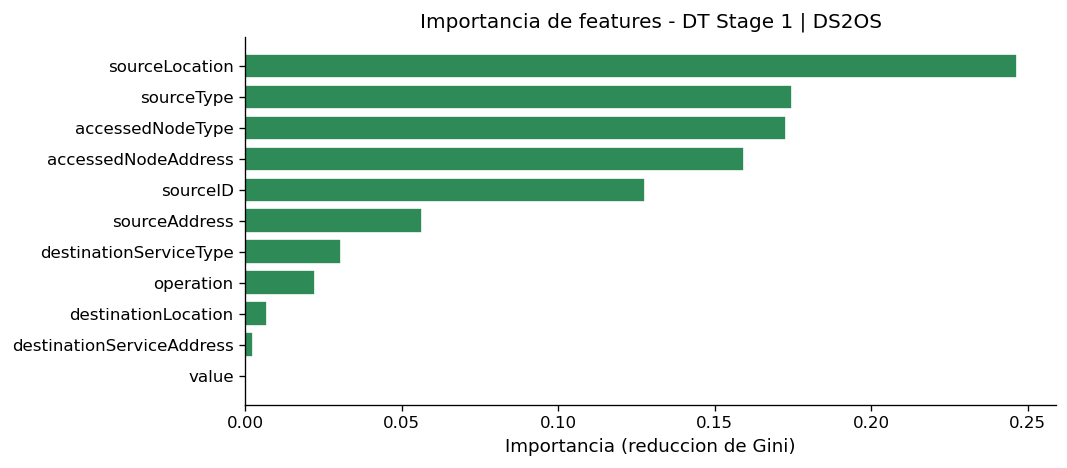

Figura guardada: dt_ds2os_importancias.png


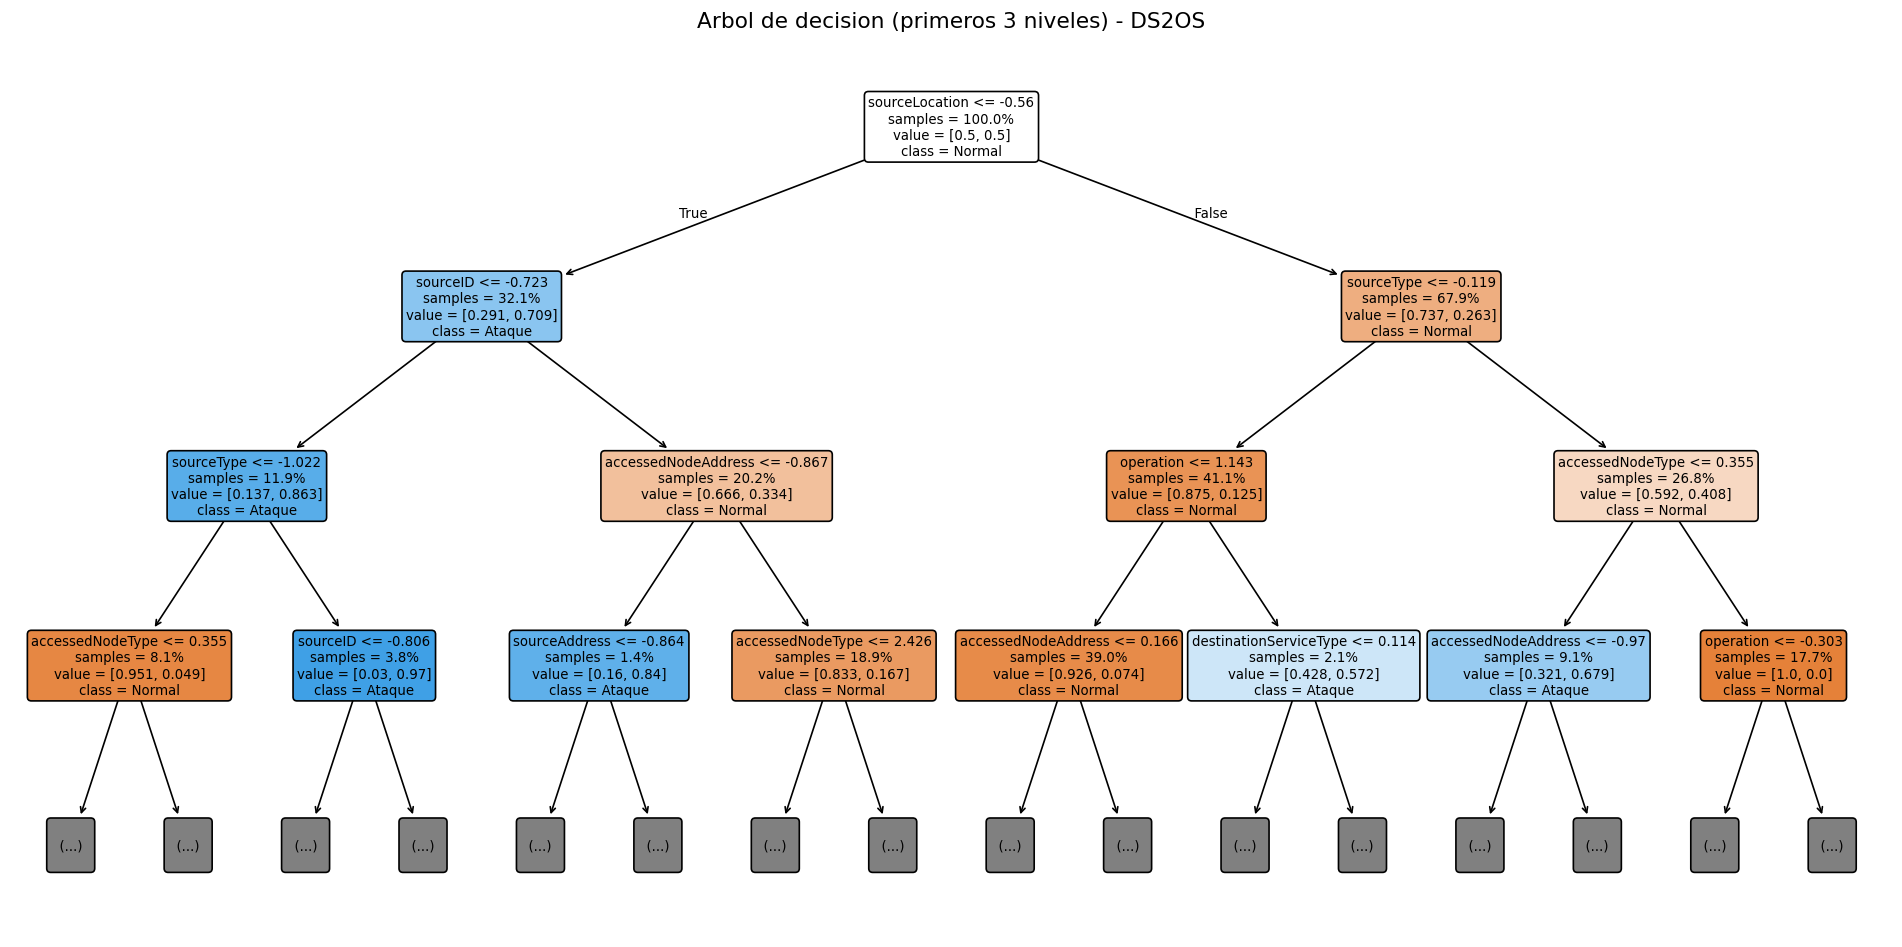

Figura guardada: dt_ds2os_arbol.png
Profundidad total del arbol: 10 | Nº hojas: 64

Reglas de decision (primeros 3 niveles):
|--- sourceLocation <= -0.56
|   |--- sourceID <= -0.72
|   |   |--- sourceType <= -1.02
|   |   |   |--- accessedNodeType <= 0.35
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- accessedNodeType >  0.35
|   |   |   |   |--- class: 1
|   |   |--- sourceType >  -1.02
|   |   |   |--- sourceID <= -0.81
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- sourceID >  -0.81
|   |   |   |   |--- truncated branch of depth 3
|   |--- sourceID >  -0.72
|   |   |--- accessedNodeAddress <= -0.87
|   |   |   |--- sourceAddress <= -0.86
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- sourceAddress >  -0.86
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- accessedNodeAddress >  -0.87
|   |   |   |--- accessedNodeType <= 2.43
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- accessedNodeType >  2.43


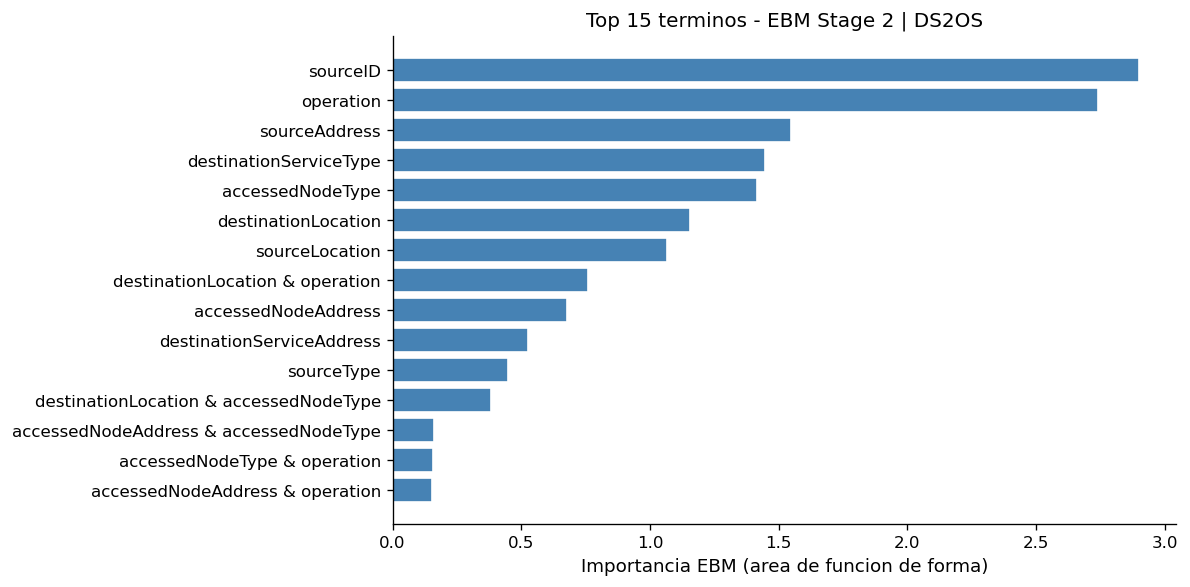

Figura guardada: ebm_ds2os_importancias.png


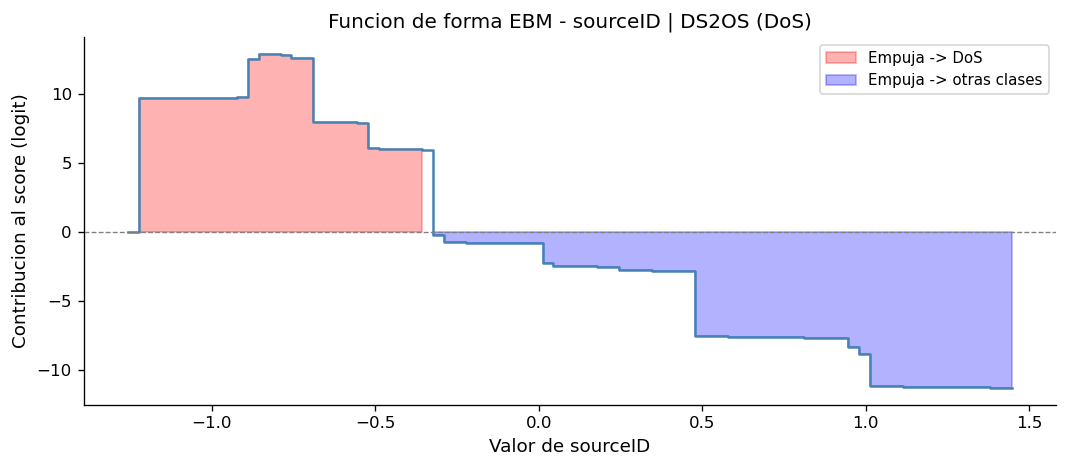

Figura guardada: ebm_ds2os_shape_sourceID.png

Explicacion local - muestra real "DoS" (idx=89)
  Prediccion EBM: Normal
  P(Normal) = 0.6731
  P(DoS) = 0.3262
  P(Scan) = 0.0007
  P(MaliciousControl) = 0.0000
  P(MaliciousOperation) = 0.0001
  P(Spying) = 0.0000
  P(DataProbing) = 0.0000
  P(WrongSetUp) = 0.0000

Top 10 contribuciones locales (EBM):
                               feature  contribucion
                destinationServiceType     -0.584857
                        sourceLocation     -0.582297
                      accessedNodeType     -0.402038
                              sourceID     -0.315833
                            sourceType      0.231164
                         sourceAddress     -0.198023
             destinationServiceAddress     -0.184219
                   accessedNodeAddress     -0.141528
                             operation     -0.070556
accessedNodeAddress & accessedNodeType     -0.064557


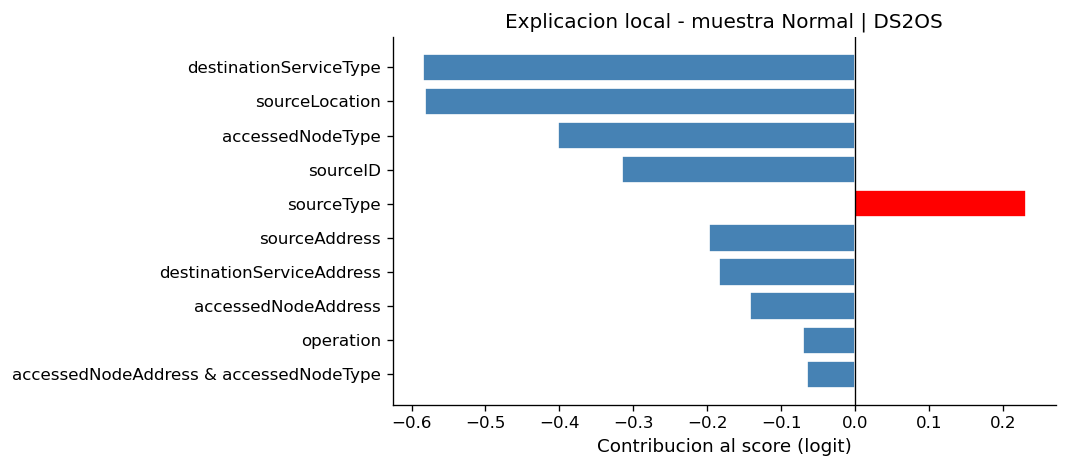

Figura guardada: ebm_ds2os_explicacion_local.png


In [ ]:
# explicabilidad DT + EBM
if DS2OS_DISPONIBLE:
    explicar_dt(dt_ds2os, FEAT_DS2OS, 'DS2OS')

    explicar_ebm(
        ebm_model=ebm_ds2os,
        X_test=Xd_te,
        y_test_multi=yd_te_multi,
        feature_names=FEAT_DS2OS,
        class_names_dict=INT_TO_CLASS,
        clase_interes=1,   # DoS
        nombre_dataset='DS2OS',
    )
else:
    print('DS2OS no disponible — bloque saltado.')


---
## COMPARATIVA FINAL — Pipeline vs EBM Directo

In [ ]:
# tabla comparativa

print('=' * 90)
print(' COMPARATIVA: Pipeline 2 Etapas vs EBM Directo'.center(90))
print('=' * 90)
print(f'{"Dataset":<12} {"Modelo":<30} {"F1-macro":>10} {"Notas":>25}')
print('-' * 90)

# NSL-KDD
nota_filt_nsl = f"filtrado {res_pipe_nsl['pct_filtered']:.0f}%"
nota_perd_nsl = f"perdidos: {res_pipe_nsl['ataques_perdidos']}"
print(f'{"NSL-KDD":<12} {"EBM directo":<30} {res_ebm_nsl["f1_macro"]:>10.4f} {nota_filt_nsl:>25}')
print(f'{"":<12} {"Pipeline DT→EBM":<30} {res_pipe_nsl["f1_macro"]:>10.4f} {nota_perd_nsl:>25}')
print('-' * 90)

# Mirai
if MIRAI_DISPONIBLE:
    nota_filt_mir = f"filtrado {res_pipe_mirai['pct_filtered']:.0f}%"
    nota_perd_mir = f"perdidos: {res_pipe_mirai['ataques_perdidos']}"
    print(f'{"Mirai":<12} {"EBM directo":<30} {res_ebm_mirai["f1_macro"]:>10.4f} {nota_filt_mir:>25}')
    print(f'{"":<12} {"Pipeline DT→EBM":<30} {res_pipe_mirai["f1_macro"]:>10.4f} {nota_perd_mir:>25}')
    print('-' * 90)

# DS2OS
if DS2OS_DISPONIBLE:
    nota_filt_ds2 = f"filtrado {res_pipe_ds2os['pct_filtered']:.0f}%"
    nota_perd_ds2 = f"perdidos: {res_pipe_ds2os['ataques_perdidos']}"
    print(f'{"DS2OS":<12} {"EBM directo":<30} {res_ebm_ds2os["f1_macro"]:>10.4f} {nota_filt_ds2:>25}')
    print(f'{"":<12} {"Pipeline DT→EBM":<30} {res_pipe_ds2os["f1_macro"]:>10.4f} {nota_perd_ds2:>25}')
    print('-' * 90)

print()
print('NOTAS:')
print('- "filtrado X%" = porcentaje de tráfico que Stage 1 descarta como normal (no llega al EBM)')
print('- "perdidos: N" = ataques reales que Stage 1 clasificó como normales (errores irrecuperables)')


                       COMPARATIVA: Pipeline 2 Etapas vs EBM Directo                      
Dataset      Modelo                           F1-macro                     Notas
------------------------------------------------------------------------------------------
NSL-KDD      EBM directo                        0.8757              filtrado 53%
             Pipeline DT→EBM                    0.8660              perdidos: 12
------------------------------------------------------------------------------------------
Mirai        EBM directo                        0.7639               filtrado 5%
             Pipeline DT→EBM                    0.7637              perdidos: 43
------------------------------------------------------------------------------------------
DS2OS        EBM directo                        0.9619              filtrado 96%
             Pipeline DT→EBM                    0.9680               perdidos: 0
---------------------------------------------------------------------

In [ ]:
# comparación temporal Pipeline vs EBM directo
# Mide latencia de predicción sobre el test set completo.
# Se repite N veces para obtener media estable.

N_REPS = 10

def medir_latencia_ebm_directo(ebm, X_test, n_reps=N_REPS):
    tiempos = []
    for _ in range(n_reps):
        t0 = time.time()
        _ = ebm.predict(X_test)
        tiempos.append(time.time() - t0)
    return np.mean(tiempos) * 1000  # ms

def medir_latencia_pipeline(dt, ebm, X_test, n_reps=N_REPS):
    tiempos = []
    for _ in range(n_reps):
        t0 = time.time()
        y_bin = dt.predict(X_test)
        mask = (y_bin == 1)
        if mask.sum() > 0:
            _ = ebm.predict(X_test[mask])
        tiempos.append(time.time() - t0)
    return np.mean(tiempos) * 1000  # ms

print('=' * 70)
print(' LATENCIA DE PREDICCIÓN (media de {} repeticiones)'.format(N_REPS).center(70))
print('=' * 70)
print(f'{"Dataset":<12} {"EBM directo":>15} {"Pipeline":>15} {"Speedup":>12}')
print('-' * 70)

# NSL-KDD
lat_ebm_nsl  = medir_latencia_ebm_directo(ebm_nsl, X_te_nsl)
lat_pipe_nsl = medir_latencia_pipeline(dt_nsl, ebm_nsl, X_te_nsl)
print(f'{"NSL-KDD":<12} {lat_ebm_nsl:>12.2f} ms {lat_pipe_nsl:>12.2f} ms {lat_ebm_nsl/lat_pipe_nsl:>10.2f}x')

# Mirai
if MIRAI_DISPONIBLE:
    lat_ebm_mir  = medir_latencia_ebm_directo(ebm_mirai, Xm_te)
    lat_pipe_mir = medir_latencia_pipeline(dt_mirai, ebm_mirai, Xm_te)
    print(f'{"Mirai":<12} {lat_ebm_mir:>12.2f} ms {lat_pipe_mir:>12.2f} ms {lat_ebm_mir/lat_pipe_mir:>10.2f}x')

# DS2OS
if DS2OS_DISPONIBLE:
    lat_ebm_ds2  = medir_latencia_ebm_directo(ebm_ds2os, Xd_te)
    lat_pipe_ds2 = medir_latencia_pipeline(dt_ds2os, ebm_ds2os, Xd_te)
    print(f'{"DS2OS":<12} {lat_ebm_ds2:>12.2f} ms {lat_pipe_ds2:>12.2f} ms {lat_ebm_ds2/lat_pipe_ds2:>10.2f}x')


           LATENCIA DE PREDICCIÓN (media de 10 repeticiones)          
Dataset          EBM directo        Pipeline      Speedup
----------------------------------------------------------------------
NSL-KDD              3.62 ms         0.67 ms       5.40x
Mirai               33.45 ms        23.36 ms       1.43x
DS2OS               50.52 ms         3.81 ms      13.25x


In [ ]:
# persistencia de modelos con joblib
import joblib

# NSL-KDD
joblib.dump(dt_nsl, 'dt_nslkdd_stage1.joblib')
joblib.dump(ebm_nsl, 'ebm_nslkdd_stage2.joblib')
print('NSL-KDD: modelos guardados')

# Mirai
if MIRAI_DISPONIBLE:
    joblib.dump(dt_mirai, 'dt_mirai_stage1.joblib')
    joblib.dump(ebm_mirai, 'ebm_mirai_stage2.joblib')
    print('Mirai: modelos guardados')

# DS2OS
if DS2OS_DISPONIBLE:
    joblib.dump(dt_ds2os, 'dt_ds2os_stage1.joblib')
    joblib.dump(ebm_ds2os, 'ebm_ds2os_stage2.joblib')
    print('DS2OS: modelos guardados')

print('\nIMPORTANTE: guarda los modelos con joblib.dump() inmediatamente.')
print('Cerrar la sesión sin guardar pierde el progreso del EBM.')


NSL-KDD: modelos guardados
Mirai: modelos guardados
DS2OS: modelos guardados

IMPORTANTE: guarda los modelos con joblib.dump() inmediatamente.
Cerrar la sesión sin guardar pierde el progreso del EBM.
